# Machine learning

## Objectifs

* Prédire si le paiement est frauduleux ou non grâce à l'apprentissage automatique

_Rq_ : l'analyse desceiprive des données est à retrouver dans `EDA.ipynb`

## Imports et lecture dataset

In [35]:
# Import des bibliothèques spécifiques aux modèles
%pip install xgboost

# Import des librairies
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import f1_score, confusion_matrix, recall_score, precision_score, classification_report, roc_auc_score, roc_curve
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

import warnings
warnings.filterwarnings("ignore")


Note: you may need to restart the kernel to use updated packages.


In [36]:
# Lecture des fichiers
print("Loading dataset...")

__file__ = os.path.abspath("ML.ipynb")  # Simuler __file__ dans un notebook

# Définir le chemin absolu du modèle
dataset_path = os.path.join(
    os.path.dirname(__file__), "..", "data", "fraudTest.csv"
)
dataset_path = os.path.normpath(dataset_path)
# os.path.dirname(__file__) permet de partir du dossier où se trouve app.py.
# .. remonte d’un niveau pour atteindre la racine du projet.

dataset = pd.read_csv(dataset_path, index_col=0)

print("...Done.")

Loading dataset...
...Done.


In [37]:
## Analyse descriptive
# INFORMATIONS GENERALES
print("\n INFORMATIONS GENERALES")
print("-" * 40)

print("Nombre de lignes (nb de transactions): {}".format(dataset.shape[0]))
print("Nombre de colonnes : {}".format(dataset.shape[1]))
print("Nombre de fraudes : {}".format(dataset["is_fraud"].sum()))

print("Aperçu du dataset : ")
display(dataset.head())

print("Types de données/colonnes : ")
display(dataset.dtypes)

# VALEURS MANQUANTES
print("\n VALEURS MANQUANTES")
print("-" * 40)

print("Nombre de valeurs manquantes par colonne :")
missing_values = dataset.isnull().sum()
missing_values_percentage = ((missing_values / dataset.shape[0]) * 100).round(
    2
)
missing_df = pd.DataFrame(
    {
        "Valeurs manquantes": missing_values,
        "Pourcentage": missing_values_percentage,
    }
)
print(missing_df[missing_df["Valeurs manquantes"] > 0])


 INFORMATIONS GENERALES
----------------------------------------
Nombre de lignes (nb de transactions): 555719
Nombre de colonnes : 22
Nombre de fraudes : 2145
Aperçu du dataset : 


,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,Columbia,...,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0
1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,Altonah,...,40.3207,-110.4360,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0
2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,Bellmore,...,40.6729,-73.5365,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0
3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,Titusville,...,28.5697,-80.8191,54767,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0
4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,Falmouth,...,44.2529,-85.0170,1126,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0


Types de données/colonnes : 


trans_date_trans_time     object
cc_num                     int64
merchant                  object
category                  object
amt                      float64
first                     object
last                      object
gender                    object
street                    object
city                      object
state                     object
zip                        int64
lat                      float64
long                     float64
city_pop                   int64
job                       object
dob                       object
trans_num                 object
unix_time                  int64
merch_lat                float64
merch_long               float64
is_fraud                   int64
dtype: object


 VALEURS MANQUANTES
----------------------------------------
Nombre de valeurs manquantes par colonne :
Empty DataFrame
Columns: [Valeurs manquantes, Pourcentage]
Index: []


## Preparation des features

In [38]:
# =====================================================
# PREPARATION FEATURES (SUR TRAIN UNIQUEMENT)
# =====================================================
# Dates
dataset["trans_date_trans_time"] = pd.to_datetime(dataset["trans_date_trans_time"])
dataset["Hour"] = dataset['trans_date_trans_time'].dt.hour
dataset["Weekday"] = dataset["trans_date_trans_time"].dt.weekday

# Distance haversine
def haversine_distance(lat1, lon1, lat2, lon2):
    r = 6371
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    delta_phi, delta_lambda = np.radians(lat2-lat1), np.radians(lon2-lon1)
    a = np.sin(delta_phi/2)**2 + np.cos(phi1)*np.cos(phi2)*np.sin(delta_lambda/2)**2
    return 2 * r * np.arcsin(np.sqrt(a))

dataset['distance_km'] = haversine_distance(
    dataset['lat'], dataset['long'], 
    dataset['merch_lat'], dataset['merch_long']
)

# Âge
dataset['age'] = pd.to_datetime(dataset["trans_date_trans_time"]).dt.year - pd.to_datetime(dataset['dob']).dt.year

# Gender encoding
dataset['gender_m'] = dataset['gender'].map({'M': 1, 'F': 0})

# Split the dataset into training and testing sets
print("\nSplit Train/Test...")
features_list = [
    "amt", "zip", "city_pop", "distance_km",
    "category",  # On garde la colonne originale
    "gender_m", "Hour", "Weekday"
]

X = dataset[features_list].copy()
y = dataset["is_fraud"]

# SPLIT STRATIFIÉ
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train : {X_train.shape[0]} samples ({y_train.sum()} fraudes)")
print(f"Test  : {X_test.shape[0]} samples ({y_test.sum()} fraudes)")

# =====================================================
# TARGET ENCODING (SUR TRAIN UNIQUEMENT)
# =====================================================
print("\nTarget Encoding...")
# Calcul UNIQUEMENT sur train
target_map = X_train.join(y_train).groupby('category')['is_fraud'].mean()

# Application
X_train['category_enc'] = X_train['category'].map(target_map)
X_test['category_enc'] = X_test['category'].map(target_map)

# Gestion des catégories inconnues
mean_fraud_rate = y_train.mean()
X_train['category_enc'].fillna(mean_fraud_rate, inplace=True)
X_test['category_enc'].fillna(mean_fraud_rate, inplace=True)

# Suppression de la colonne originale
X_train = X_train.drop('category', axis=1)
X_test = X_test.drop('category', axis=1)


# 5. STANDARDISATION (SUR TRAIN UNIQUEMENT)
# =====================================================
print("\n Standardisation...")
num_features = ["amt", "zip", "city_pop", "distance_km", "Hour", "Weekday"]
scaler = StandardScaler()

# Fit sur train, transform sur train et test
X_train[num_features] = scaler.fit_transform(X_train[num_features])
X_test[num_features] = scaler.transform(X_test[num_features])

# =====================================================
# 6. SMOTE (SUR TRAIN UNIQUEMENT)
# =====================================================
print("\nApplication de SMOTE...")
print(f"Avant SMOTE : {y_train.sum()} fraudes / {len(y_train)} total")

smote = SMOTE(random_state=42, sampling_strategy=0.5)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(f"Après SMOTE : {y_train_resampled.sum()} fraudes / {len(y_train_resampled)} total")


Split Train/Test...
Train : 444575 samples (1716 fraudes)
Test  : 111144 samples (429 fraudes)

Target Encoding...

 Standardisation...

Application de SMOTE...
Avant SMOTE : 1716 fraudes / 444575 total
Après SMOTE : 221429 fraudes / 664288 total


### Implémentation du modèle


 Entraînement des modèles...

Entraînement RandomForest...
F1-Score : 0.7477
Recall   : 0.6667
Precision: 0.8512
Seuil optimal: 0.58

Entraînement XGBoost...
F1-Score : 0.7672
Recall   : 0.6876
Precision: 0.8676
Seuil optimal: 0.86

RÉSULTATS FINAUX SUR TEST SET
      Modèle  F1-Score   Recall  Precision  Seuil
     XGBoost  0.767230 0.687646   0.867647   0.86
RandomForest  0.747712 0.666667   0.851190   0.58


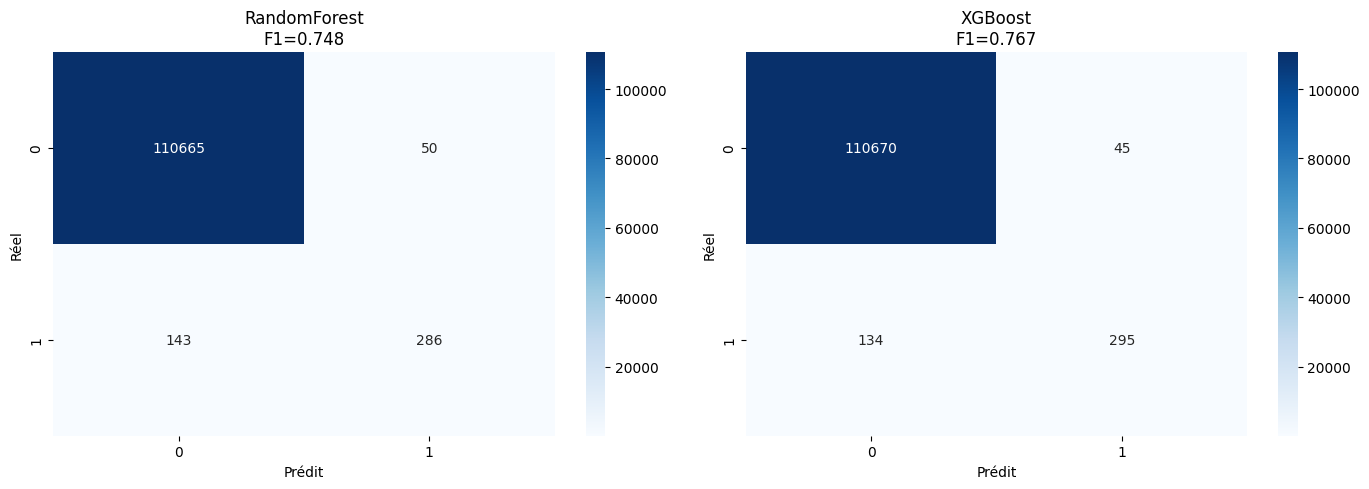


ENTRAÎNEMENT TERMINÉ - Scores HONNÊTES et FIABLES !

 Visualisation de l'importance des features...


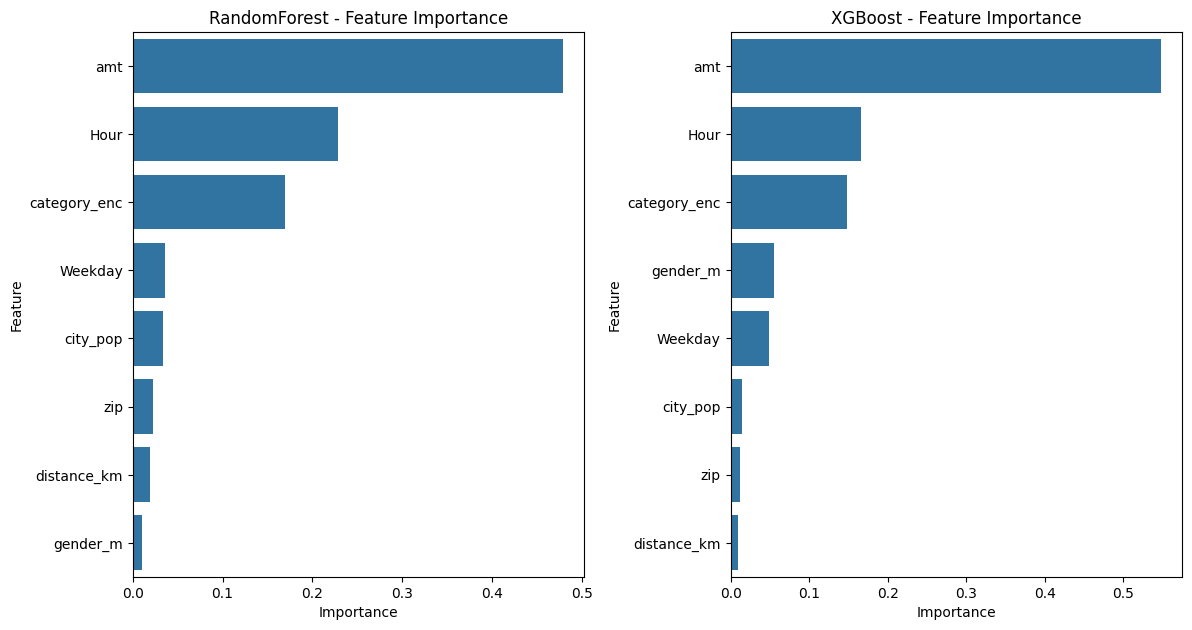

In [39]:
# =====================================================
# ENTRAÎNEMENT ET ÉVALUATION
# =====================================================
print("\n Entraînement des modèles...")

models = {
    "RandomForest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "XGBoost": XGBClassifier(eval_metric="logloss", random_state=42)
}

results = {}

for name, model in models.items():
    print(f"\nEntraînement {name}...")
    
    # ENTRAÎNEMENT SUR DONNÉES RESAMPLED
    model.fit(X_train_resampled, y_train_resampled)
    
    # ÉVALUATION SUR TEST SET (données JAMAIS vues)
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    # Recherche du meilleur seuil
    best_f1 = 0
    best_threshold = 0.5
    for threshold in np.arange(0.1, 0.9, 0.01):
        y_pred_thresh = (y_pred_proba >= threshold).astype(int)
        f1 = f1_score(y_test, y_pred_thresh)
        if f1 > best_f1:
            best_f1 = f1
            best_threshold = threshold
    
    # Prédiction finale avec le meilleur seuil
    y_pred_final = (y_pred_proba >= best_threshold).astype(int)
    
    results[name] = {
        'f1': f1_score(y_test, y_pred_final),
        'recall': recall_score(y_test, y_pred_final),
        'precision': precision_score(y_test, y_pred_final),
        'threshold': best_threshold,
        'cm': confusion_matrix(y_test, y_pred_final)
    }
    
    print(f"F1-Score : {results[name]['f1']:.4f}")
    print(f"Recall   : {results[name]['recall']:.4f}")
    print(f"Precision: {results[name]['precision']:.4f}")
    print(f"Seuil optimal: {best_threshold:.2f}")

# =====================================================
# AFFICHAGE RÉSULTATS
# =====================================================
print("\n" + "="*60)
print("RÉSULTATS FINAUX SUR TEST SET")
print("="*60)

results_df = pd.DataFrame({
    'Modèle': list(results.keys()),
    'F1-Score': [results[m]['f1'] for m in results.keys()],
    'Recall': [results[m]['recall'] for m in results.keys()],
    'Precision': [results[m]['precision'] for m in results.keys()],
    'Seuil': [results[m]['threshold'] for m in results.keys()]
}).sort_values('F1-Score', ascending=False)

print(results_df.to_string(index=False))

# =====================================================
# VISUALISATION MATRICES DE CONFUSION
# =====================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, (name, res) in enumerate(results.items()):
    cm = res['cm']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx])
    axes[idx].set_title(f"{name}\nF1={res['f1']:.3f}")
    axes[idx].set_xlabel("Prédit")
    axes[idx].set_ylabel("Réel")

plt.tight_layout()
plt.show()

print("\nENTRAÎNEMENT TERMINÉ - Scores HONNÊTES et FIABLES !")
print("="*60)

# =====================================================
# VISUALISATION FEATURES IMPORTANCE
# =====================================================

print("\n Visualisation de l'importance des features...")

# Dictionnaire pour stocker importances
importances = {}

for name, model in models.items():
    # Les modèles ont déjà été entraînés dans la boucle précédente
    if name == "LogisticRegression":
        importances[name] = pd.DataFrame(
            {"Feature": X_train.columns, "Coefficient": model.coef_[0]}
        ).sort_values(by="Coefficient", ascending=False)
    else:
        importances[name] = pd.DataFrame(
            {
                "Feature": X_train.columns,
                "Importance": model.feature_importances_,
            }
        ).sort_values(by="Importance", ascending=False)


plt.figure(figsize=(18, 12))

for i, (name, df) in enumerate(importances.items(), 1):
    plt.subplot(2, 3, i)
    if name == "XGBoost":
        sns.barplot(x="Importance", y="Feature", data=df)
        plt.title(f"{name} - Feature Importance")
    else:
        sns.barplot(x="Importance", y="Feature", data=df)
        plt.title(f"{name} - Feature Importance")


plt.tight_layout()
plt.show()

### Analyse des scores et choix du modèle

- F1-Score : 

- Recall : 

- Precision : 

- ROC-AUC : 

Lecture de la matrice de confusion


Lecture des features importances

CHOIX 

### Optimisation du modèle XGBoost

In [40]:
# =====================================================
# RECHERCHE DES MEILLEURS PARAMETRES
# =====================================================
print("\n Recherche des meilleurs paramètres...")

# Définition de la grille de paramètres
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0]
}

# Initialisation du modèle
xgb_model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')

# Recherche de la meilleure combinaison (GridSearch)
grid_search = GridSearchCV(estimator=xgb_model, param_grid=param_grid, 
                           cv=3, scoring='f1', n_jobs=-1, verbose=1)

grid_search.fit(X_train, y_train)

print(f"Meilleurs paramètres : {grid_search.best_params_}")
best_model = grid_search.best_estimator_


 Recherche des meilleurs paramètres...
Fitting 3 folds for each of 36 candidates, totalling 108 fits
Meilleurs paramètres : {'learning_rate': 0.1, 'max_depth': 8, 'n_estimators': 200, 'subsample': 1.0}


In [41]:
# =====================================================
# ENTRAÎNEMENT SUR LES DONNÉES RESAMPLED
# =====================================================
print("\n Entraînement sur les données resampled avec les meilleurs paramètres...")

best_model.fit(X_train_resampled, y_train_resampled)
print("Entraînement terminé")
    
# =====================================================
# 9. Évaluation sur TEST SET (données JAMAIS vues)
# =====================================================
print("\nÉvaluation sur le Test Set...")

y_pred = best_model.predict(X_test)
y_pred_proba = best_model.predict_proba(X_test)[:, 1]

# Métriques
f1 = f1_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
    
print(f"\n{'='*50}")
print(f"RÉSULTATS SUR TEST SET")
print(f"{'='*50}")
print(f"F1 Score   : {f1:.4f}")
print(f"Recall     : {recall:.4f} (% de fraudes détectées)")
print(f"Precision  : {precision:.4f} (% de prédictions correctes)")
print(f"{'='*50}\n")
    
# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
print("Matrice de Confusion :")
print(f"  TN={cm[0,0]:6d} | FP={cm[0,1]:6d}")
print(f"  FN={cm[1,0]:6d} | TP={cm[1,1]:6d}")
print()
    
# Classification report
print("Classification Report :")
print(classification_report(y_test, y_pred, target_names=['Légal', 'Fraude']))

# =====================================================
# 10. Feature Importance
# =====================================================
print("\nFeature Importance :")
fi = model.feature_importances_
features = X_train.columns
importance_df = pd.DataFrame({
    'Feature': features, 
    'Importance': fi
}).sort_values(by='Importance', ascending=False)
print(importance_df.to_string(index=False))


 Entraînement sur les données resampled avec les meilleurs paramètres...
Entraînement terminé

Évaluation sur le Test Set...

RÉSULTATS SUR TEST SET
F1 Score   : 0.7288
Recall     : 0.7925 (% de fraudes détectées)
Precision  : 0.6746 (% de prédictions correctes)

Matrice de Confusion :
  TN=110551 | FP=   164
  FN=    89 | TP=   340

Classification Report :
              precision    recall  f1-score   support

       Légal       1.00      1.00      1.00    110715
      Fraude       0.67      0.79      0.73       429

    accuracy                           1.00    111144
   macro avg       0.84      0.90      0.86    111144
weighted avg       1.00      1.00      1.00    111144


Feature Importance :
     Feature  Importance
         amt    0.547459
        Hour    0.165848
category_enc    0.147571
    gender_m    0.054723
     Weekday    0.048889
    city_pop    0.014809
         zip    0.011602
 distance_km    0.009099


In [42]:
# Sauvegarde du modèle entraîné
best_model.save_model("xgboost_model.cbm")
print(" Modèle XGBoost sauvegardé sous 'xgboost_model.cbm'")


# Chargement du modèle sauvegardé
loaded_model = XGBClassifier()
loaded_model.load_model("xgboost_model.cbm")
print(" Modèle rechargé avec succès")

 Modèle XGBoost sauvegardé sous 'xgboost_model.cbm'
 Modèle rechargé avec succès
